Load in libraries 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix



root = "/home/amzeplin/plant_village_dataset"

In [2]:
import torch
import os
from PIL import Image
from torchvision import transforms

class PlantVillage(torch.utils.data.Dataset):
    def __init__(self, root: str, split: str, transform=None):
        self.root = root
        self.species = os.listdir(self.root)
        self.img_split = split
        self.transform = transform
        self.data = self.__load_files()

        # Create label_map to map species_disease to a numeric index
        unique_labels = sorted(set(f"{species}_{disease}" for _, species, disease in self.data))
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_file, species, disease_class = self.data[idx]
        img = Image.open(img_file).convert("RGB")

        if self.transform:
            img = self.transform(img)

        # Convert label from string to tensor index
        label = self.label_map[f"{species}_{disease_class}"]
        label = torch.tensor(label, dtype=torch.long)

        return img, label

    def __load_files(self):
        data = []
        for specie in self.species:
            specie_path = os.path.join(self.root, specie, self.img_split)
            if not os.path.exists(specie_path): 
                continue

            for disease in os.listdir(specie_path):
                disease_path = os.path.join(specie_path, disease)
                if not os.path.isdir(disease_path):
                    continue

                images = [img for img in os.listdir(disease_path) if not img.startswith('.')]

                data.extend([(os.path.join(disease_path, img), specie, disease) for img in images])

        return data


Data Augmentations and Dataloaders 

In [3]:
train_augmentations = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_ds = PlantVillage(
            root=root,
            split="Train",
            transform=train_augmentations,
        )

val_ds = PlantVillage(
            root=root,
            split="Val",
            transform=train_augmentations,
        )

test_ds = PlantVillage(
            root=root,
            split="Test",
            transform=train_augmentations,
        )

train_loader = torch.utils.data.DataLoader(
    dataset=train_ds,
    batch_size=64,
    num_workers=2,
    drop_last=False,
    persistent_workers=False,
    shuffle=True,
    pin_memory=True,
)

val_loader = torch.utils.data.DataLoader(
    dataset=val_ds,
    batch_size=32,
    num_workers=0,
    drop_last=True,
    persistent_workers=False,
    shuffle=False,
    pin_memory=True,
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_ds,
    batch_size=32,
    num_workers=0,
    drop_last=True,
    persistent_workers=False,
    shuffle=False,
    pin_memory=True,
)

In [4]:
import torch.nn as nn

# Patch Embedding: turn image into patch tokens
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=16, emb_size=256, img_size=224): #RGB, 16x16 patch size, vector size of 256, and iamge size of 224x224
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size) #Slice images into non-overlapping patches and convert each patch into a vector size of 256
        self.n_patches = (img_size // patch_size) ** 2 #64 patches total

    def forward(self, x):
        x = self.proj(x)       #Apply the Conv2D to split and embed the patches     # [B, E, H/P, W/P]
        x = x.flatten(2).transpose(1, 2)  #Flattens the last 2 dimensions    # [B, N, E]
        return x

# Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size=256, heads=8, ff_hidden=512, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(emb_size)
        self.mha = nn.MultiheadAttention(emb_size, heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(emb_size)
        self.ff = nn.Sequential(
            nn.Linear(emb_size, ff_hidden),
            nn.GELU(),
            nn.Linear(ff_hidden, emb_size)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x_res = x
        x = self.ln1(x)
        x, _ = self.mha(x, x, x)
        x = x_res + self.dropout(x)

        x_res = x
        x = self.ln2(x)
        x = self.ff(x)
        x = x_res + self.dropout(x)
        return x

# Full Vision Transformer
class SimpleViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, emb_size=256, num_layers=6, num_heads=8, num_classes=10): #Cuts image in equal squares 
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size=patch_size, emb_size=emb_size, img_size=img_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))  #Adds a summary token  - puts the most important information into token
        self.pos_embed = nn.Parameter(torch.randn(1, (img_size // patch_size) ** 2 + 1, emb_size)) #Add positional embeddings to tell the model where the patch came from and include the token 

        self.encoder = nn.Sequential(
            *[TransformerEncoderBlock(emb_size, num_heads) for _ in range(num_layers)]
        )  #Core of the transformers to stack multiple encoder block and update based on what's relevant 

        self.norm = nn.LayerNorm(emb_size) #Normalizes the patch vectors to stabilize training - not too high or low 
        self.head = nn.Linear(emb_size, num_classes) #Takes all token and predicts the class 

    def forward(self, x):
        B = x.size(0) #Gets patch sisze 
        x = self.patch_embed(x)  # [B, N, E] #Turn each image into a sequence of patch vectors 
        cls_token = self.cls_token.expand(B, -1, -1)  # [B, 1, E]  #add CLS token to every patch 
        x = torch.cat([cls_token, x], dim=1)          # [B, N+1, E]  #add the CLS token to the beginning of each patch to summarize whole image 
        x = x + self.pos_embed #Gives each patch a position
        x = self.encoder(x)  #Pass each patch through the transformer layers
        x = self.norm(x[:, 0])                        # Use [CLS] token only that holds the summary of the image 
        x = self.head(x)    #Final Classififcation Layer    #Takes CLS vector and outputs num_classes 
        return x


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = SimpleViT(
    img_size=128,       # match resized image
    patch_size=16,
    emb_size=128,       # smaller embedding size
    num_layers=3,       # fewer transformer blocks
    num_heads=4,        # fewer heads
    num_classes=29
).to(device)


In [6]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [7]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad() #Resets gradients from last batch 
        outputs = model(imgs)  #Forward pass - makes predictions for this batch of images 
        loss = criterion(outputs, labels) 
        loss.backward()  #Backproporgation calculates how wrong the model is 
        optimizer.step()  #Updates the model weights 

        total_loss += loss.item()  #Adds the loss from batch to total 
        _, preds = torch.max(outputs, 1)   #Gets the predicted class 
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    avg_loss = total_loss / len(dataloader)
    return avg_loss, acc


In [8]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    avg_loss = total_loss / len(dataloader)
    return avg_loss, acc


In [9]:
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)


Epoch 1/20
Train Loss: 1.8785 | Train Acc: 0.4771
Val   Loss: 1.0183 | Val   Acc: 0.7041
--------------------------------------------------
Epoch 2/20
Train Loss: 0.9055 | Train Acc: 0.7319
Val   Loss: 0.6286 | Val   Acc: 0.8100
--------------------------------------------------
Epoch 3/20
Train Loss: 0.6555 | Train Acc: 0.8018
Val   Loss: 0.4889 | Val   Acc: 0.8469
--------------------------------------------------
Epoch 4/20
Train Loss: 0.5304 | Train Acc: 0.8352
Val   Loss: 0.4288 | Val   Acc: 0.8596
--------------------------------------------------
Epoch 5/20
Train Loss: 0.4515 | Train Acc: 0.8569
Val   Loss: 0.3479 | Val   Acc: 0.8898
--------------------------------------------------
Epoch 6/20
Train Loss: 0.4041 | Train Acc: 0.8697
Val   Loss: 0.3233 | Val   Acc: 0.8937
--------------------------------------------------
Epoch 7/20
Train Loss: 0.3605 | Train Acc: 0.8829
Val   Loss: 0.2943 | Val   Acc: 0.9029
--------------------------------------------------
Epoch 8/20
Train Los

In [14]:
# Save model weights and label map
torch.save({
    'model_state_dict': model.state_dict(),
    'label_map': train_ds.label_map
}, 'vit_plantvillage.pth')

print(" Model saved to vit_plantvillage.pth")


 Model saved to vit_plantvillage.pth


In [9]:
# Load checkpoint first (map_location='cuda' if you're using GPU)
checkpoint = torch.load('vit_plantvillage.pth', map_location='cpu')

# Get label map from checkpoint
label_map = checkpoint['label_map']
num_classes = len(label_map)

# Now recreate the model using that info
model = SimpleViT(
    img_size=128,       # match resized image
    patch_size=16,
    emb_size=128,       # smaller embedding size
    num_layers=3,       # fewer transformer blocks
    num_heads=4,        # fewer heads
    num_classes=num_classes
)

# Load model weights
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(" Model loaded with", num_classes, "classes.")


 Model loaded with 29 classes.


Confusion Matrix

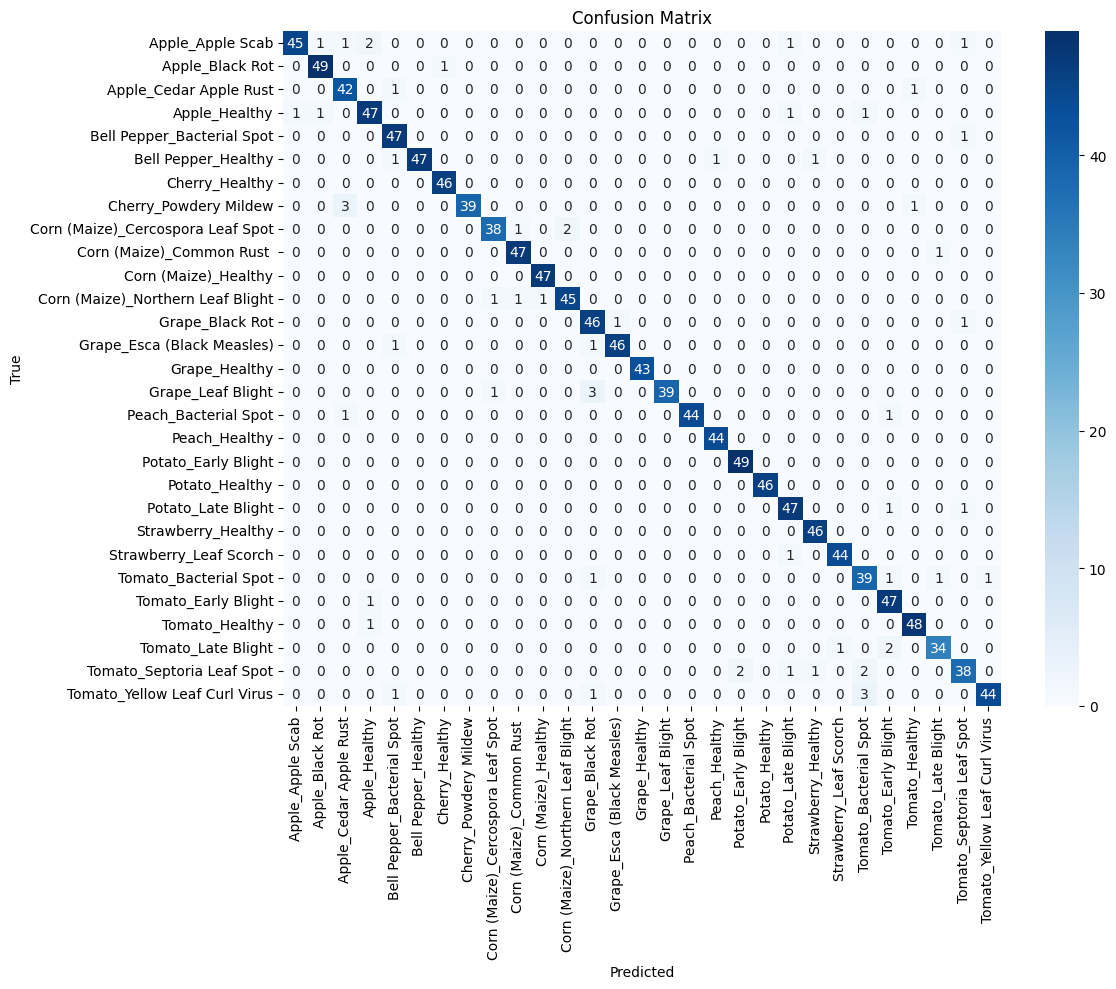

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get all predictions and true labels
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = list(label_map.keys())

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [38]:
def plot_attention_maps(model, dataloader, label_map, device, num_images=3):
    import matplotlib.pyplot as plt
    import numpy as np
    import torch.nn as nn

    model.eval()
    inputs, labels = next(iter(dataloader))
    indices = np.random.choice(inputs.shape[0], size=num_images, replace=False)
    inputs = inputs[indices].to(device)
    labels = labels[indices].to(device)

    attn_weights = None

    with torch.no_grad():
        B = inputs.size(0)
        x = model.patch_embed(inputs)
        cls_token = model.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + model.pos_embed

        for i, block in enumerate(model.encoder):
            x_ln = block.ln1(x)

            safe_mha = nn.MultiheadAttention(
                embed_dim=block.mha.embed_dim,
                num_heads=block.mha.num_heads,
                dropout=0.0,
                batch_first=True
            ).to(device)
            safe_mha.load_state_dict(block.mha.state_dict())
            safe_mha.eval()

            attn_output, attn_weights = safe_mha(
                x_ln, x_ln, x_ln,
                need_weights=True,
                average_attn_weights=False
            )

            x = x + block.dropout(attn_output)
            x = x + block.dropout(block.ff(block.ln2(x)))

        _ = model.head(model.norm(x[:, 0]))

    attn = attn_weights.detach().cpu()  # [B, Heads, Tokens, Tokens]
    num_heads = attn.shape[1]
    idx_to_class = {v: k for k, v in label_map.items()}

    # Plot: num_images rows × (num_heads + 2) cols (input + each head + avg map)
    fig, axes = plt.subplots(num_images, num_heads + 2, figsize=(3 * (num_heads + 2), 3 * num_images))
    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        rgb_img = inputs[i].cpu().permute(1, 2, 0).numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

        # Input image
        ax = axes[i][0]
        ax.imshow(rgb_img)
        ax.axis("off")
        ax.set_ylabel(idx_to_class[int(labels[i])], fontsize=12)
        if i == 0:
            ax.set_title("Input")

        # Each attention head
        for h in range(num_heads):
            map_ = attn[i, h, 0, 1:]
            patch_size = int(np.sqrt(map_.shape[0]))
            map_ = map_.reshape(patch_size, patch_size).numpy()
            map_ = (map_ - map_.min()) / (map_.max() - map_.min() + 1e-8)

            ax = axes[i][h + 1]
            ax.imshow(rgb_img)
            ax.imshow(map_, cmap='viridis', alpha=0.5,
                      extent=(0, rgb_img.shape[1], rgb_img.shape[0], 0))
            ax.axis("off")
            if i == 0:
                ax.set_title(f"Head {h}")

        # Average attention map
        avg_map = attn[i, :, 0, 1:].mean(0)  # Average across heads
        patch_size = int(np.sqrt(avg_map.shape[0]))
        avg_map = avg_map.reshape(patch_size, patch_size).numpy()
        avg_map = (avg_map - avg_map.min()) / (avg_map.max() - avg_map.min() + 1e-8)

        ax = axes[i][num_heads + 1]
        ax.imshow(rgb_img)
        ax.imshow(avg_map, cmap='viridis', alpha=0.5,
                  extent=(0, rgb_img.shape[1], rgb_img.shape[0], 0))
        ax.axis("off")
        if i == 0:
            ax.set_title("Avg Heads")

    plt.tight_layout()
    plt.show()


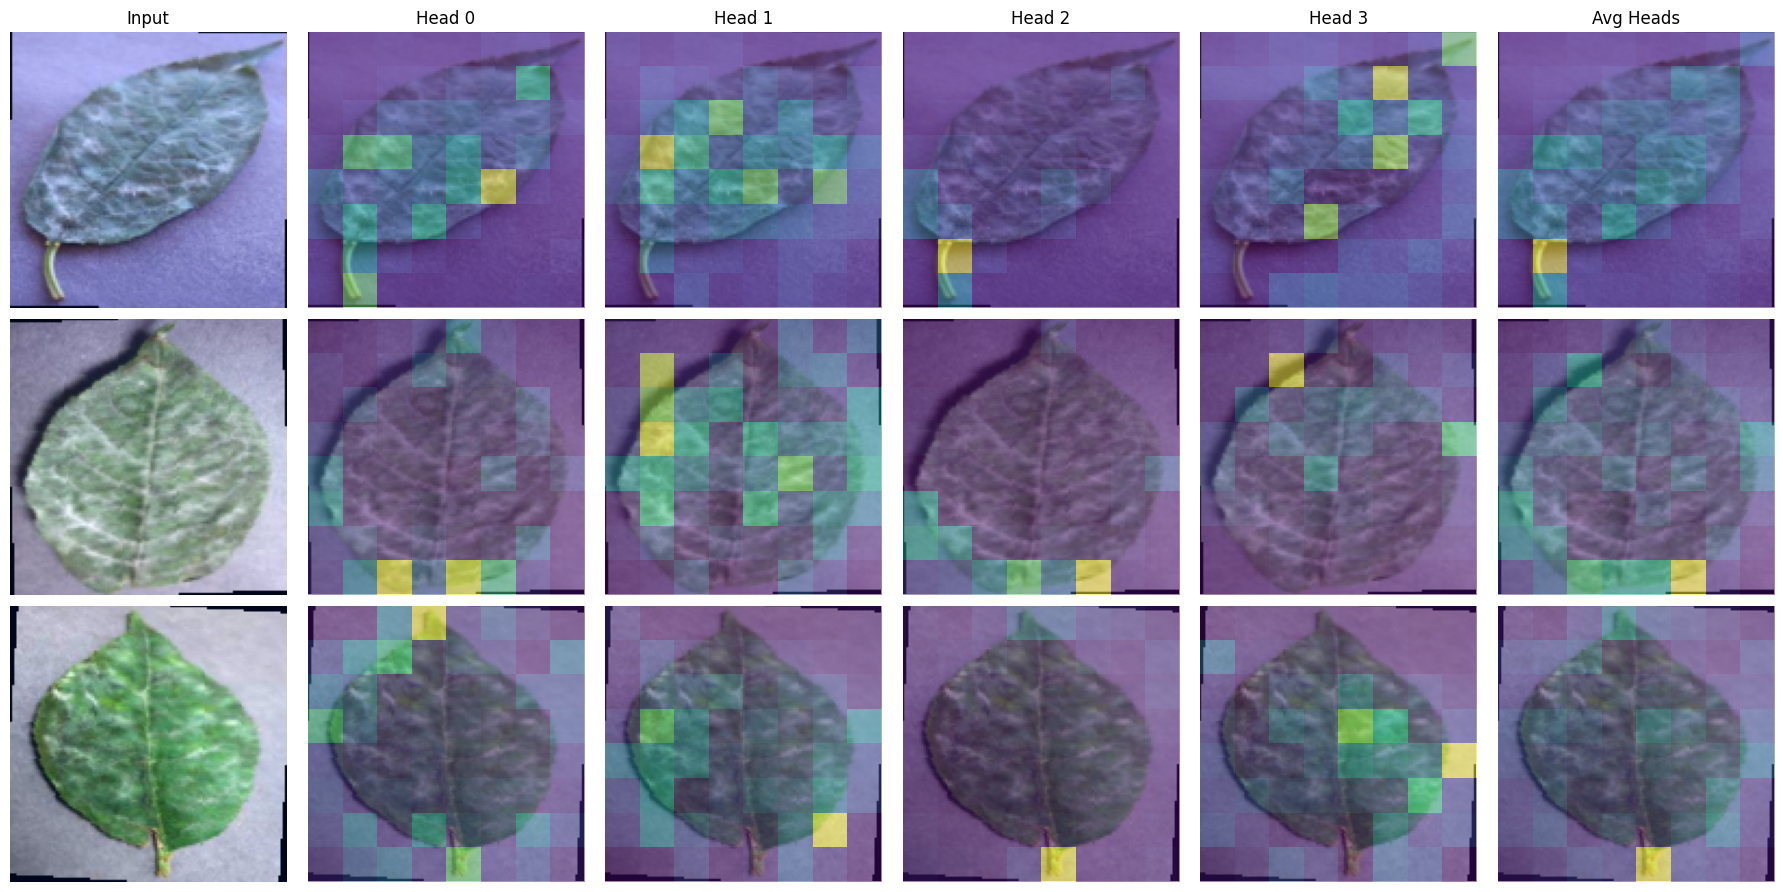

In [ ]:
plot_attention_maps(
    model=model,
    dataloader=test_loader,
    label_map=test_ds.label_map,
    device=device,
    num_images=3
)


In [50]:
checkpoint = torch.load("vit_plantvillage.pth", map_location=device)

model = SimpleViT(
    img_size=128,
    patch_size=16,
    emb_size=128,
    num_layers=3,
    num_heads=4,
    num_classes=len(checkpoint['label_map'])
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 1. Classification Report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=list(label_map.keys())))


# 2 Specificity per class
specificity_per_class = []
for i in range(len(cm)):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    specificity = TN / (TN + FP + 1e-8)
    specificity_per_class.append(specificity)

print("\nSpecificity per class:")
for idx, class_name in enumerate(label_map.keys()):
    print(f"{class_name}: {specificity_per_class[idx]:.4f}")



Classification Report:
                                   precision    recall  f1-score   support

                 Apple_Apple Scab       0.98      0.86      0.92        51
                  Apple_Black Rot       0.92      0.96      0.94        50
           Apple_Cedar Apple Rust       0.93      0.98      0.96        44
                    Apple_Healthy       0.93      1.00      0.96        51
       Bell Pepper_Bacterial Spot       0.94      0.96      0.95        48
              Bell Pepper_Healthy       1.00      0.94      0.97        50
                   Cherry_Healthy       0.98      1.00      0.99        46
            Cherry_Powdery Mildew       0.98      0.98      0.98        43
Corn (Maize)_Cercospora Leaf Spot       0.97      0.85      0.91        41
        Corn (Maize)_Common Rust        0.98      0.98      0.98        48
             Corn (Maize)_Healthy       0.96      1.00      0.98        47
Corn (Maize)_Northern Leaf Blight       0.90      0.94      0.92        48


In [10]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

def evaluate_metrics(model, dataloader, label_map, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # --- Overall Metrics ---
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    recall_macro = recall_score(all_labels, all_preds, average='macro')

    # Specificity needs confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    specificity_per_class = []
    for i in range(len(cm)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(cm, i, axis=0)[:, i])
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_per_class.append(specificity)

    specificity_macro = np.mean(specificity_per_class)

    print(f"Overall Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (macro average): {f1_macro:.4f}")
    print(f"Sensitivity/Recall (macro average): {recall_macro:.4f}")
    print(f"Specificity (macro average): {specificity_macro:.4f}")

    # --- Per-Class Metrics ---
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    recall_per_class = recall_score(all_labels, all_preds, average=None)

    print("\nPer-Class Metrics:")
    idx_to_label = {v: k for k, v in label_map.items()}
    for idx, label in idx_to_label.items():
        print(f"{label}:")
        print(f"  F1 Score: {f1_per_class[idx]:.4f}")
        print(f"  Sensitivity/Recall: {recall_per_class[idx]:.4f}")
        print(f"  Specificity: {specificity_per_class[idx]:.4f}")


In [11]:
evaluate_metrics(model, val_loader, label_map, device)

Overall Metrics:
Accuracy: 0.9523
F1 Score (macro average): 0.9525
Sensitivity/Recall (macro average): 0.9523
Specificity (macro average): 0.9983

Per-Class Metrics:
Apple_Apple Scab:
  F1 Score: 0.9012
  Sensitivity/Recall: 0.8455
  Specificity: 0.9988
Apple_Black Rot:
  F1 Score: 0.9362
  Sensitivity/Recall: 0.9687
  Specificity: 0.9961
Apple_Cedar Apple Rust:
  F1 Score: 0.9431
  Sensitivity/Recall: 0.9621
  Specificity: 0.9973
Apple_Healthy:
  F1 Score: 0.9523
  Sensitivity/Recall: 0.9512
  Specificity: 0.9982
Bell Pepper_Bacterial Spot:
  F1 Score: 0.9559
  Sensitivity/Recall: 0.9837
  Specificity: 0.9972
Bell Pepper_Healthy:
  F1 Score: 0.9300
  Sensitivity/Recall: 0.9217
  Specificity: 0.9977
Cherry_Healthy:
  F1 Score: 0.9760
  Sensitivity/Recall: 0.9902
  Specificity: 0.9986
Cherry_Powdery Mildew:
  F1 Score: 0.9732
  Sensitivity/Recall: 0.9603
  Specificity: 0.9996
Corn (Maize)_Cercospora Leaf Spot:
  F1 Score: 0.9304
  Sensitivity/Recall: 0.9051
  Specificity: 0.9987
Corn (M